In [1]:
import pandas as pd
import numpy as np

In [2]:
data = pd.read_csv("upload.csv")

In [3]:
data

,Id,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,1,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,2,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,3,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,4,http://rgipt.ac.in,18,11,0,2,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,5,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5452,5453,http://www.danielbranch.com/,28,20,0,2,0,0,0,0,...,1,0,0,1210,2806,866959,0,0,4,legitimate
5453,5454,http://justsayingbro.com/ncb/rcn.imse/rnr/abur...,50,17,0,3,0,0,0,0,...,1,0,0,190,2732,0,0,1,2,phishing
5454,5455,http://ipack-dsk-ship.com/6S5Z5Z78FZ1ZA0SA18AZ...,98,18,1,1,2,0,0,0,...,1,0,0,143,-1,0,0,1,0,phishing
5455,5456,http://oneaim.lu/llbs,21,9,0,1,0,0,0,0,...,1,0,0,0,-1,0,0,1,0,phishing


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5457 entries, 0 to 5456
Data columns (total 90 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Id                          5457 non-null   int64  
 1   url                         5457 non-null   object 
 2   length_url                  5457 non-null   int64  
 3   length_hostname             5457 non-null   int64  
 4   ip                          5457 non-null   int64  
 5   nb_dots                     5457 non-null   int64  
 6   nb_hyphens                  5457 non-null   int64  
 7   nb_at                       5457 non-null   int64  
 8   nb_qm                       5457 non-null   int64  
 9   nb_and                      5457 non-null   int64  
 10  nb_or                       5457 non-null   int64  
 11  nb_eq                       5457 non-null   int64  
 12  nb_underscore               5457 non-null   int64  
 13  nb_tilde                    5457 

In [5]:
data['url'].unique()

array(['http://www.crestonwood.com/router.php',
       'http://shadetreetechnology.com/V4/validation/a111aedc8ae390eabcfa130e041a10a4',
       'https://support-appleld.com.secureupdate.duilawyeryork.com/ap/89e6a3b4b063b8d/?cmd=_update&dispatch=89e6a3b4b063b8d1b&locale=_',
       ...,
       'http://ipack-dsk-ship.com/6S5Z5Z78FZ1ZA0SA18AZ/5AZD5A5ZZ6DAZ98FAZ6565SAZ/9S6Z6S12565110DDEDZ/TRACK',
       'http://oneaim.lu/llbs',
       'https://storiediunabarbomamma.wordpress.com/'], dtype=object)

In [6]:
data['status'].unique()

array(['legitimate', 'phishing'], dtype=object)

In [7]:
data[data['status']== 'legitimate'].shape

(2720, 90)

In [8]:
data[data['status']== 'phishing'].shape

(2737, 90)

In [11]:
import seaborn as sns

In [12]:
X = data['url']

In [13]:
X

0                   http://www.crestonwood.com/router.php
1       http://shadetreetechnology.com/V4/validation/a...
2       https://support-appleld.com.secureupdate.duila...
3                                      http://rgipt.ac.in
4       http://www.iracing.com/tracks/gateway-motorspo...
                              ...                        
5452                         http://www.danielbranch.com/
5453    http://justsayingbro.com/ncb/rcn.imse/rnr/abur...
5454    http://ipack-dsk-ship.com/6S5Z5Z78FZ1ZA0SA18AZ...
5455                                http://oneaim.lu/llbs
5456         https://storiediunabarbomamma.wordpress.com/
Name: url, Length: 5457, dtype: object

In [14]:
y = data['status']

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [16]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english', max_df=0.7)

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_vectorizer= TfidfVectorizer(min_df=1,stop_words='english')

In [18]:
tfidf_train = tfidf_vectorizer.fit_transform(X) 

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(tfidf_train, y, test_size=0.3, random_state=250)
print(X_train.shape)
print(X_test.shape)

(3819, 11578)
(1638, 11578)


In [20]:
X_train

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 28068 stored elements and shape (3819, 11578)>

In [21]:
from sklearn.ensemble import RandomForestClassifier



# instantiate the classifier 

rfc = RandomForestClassifier(random_state=0)

In [22]:
rfc.fit(X_train,y_train)

RandomForestClassifier(random_state=0)

In [23]:
print(rfc.score(X_train,y_train))

1.0


In [24]:
from sklearn.metrics import accuracy_score
y_pred = rfc.predict(X_test )
accuracy_score(y_pred,y_test)

0.8852258852258852

In [25]:
import sklearn.metrics

In [26]:
print(sklearn.metrics.classification_report(y_test, y_pred))

              precision    recall  f1-score   support

  legitimate       0.89      0.87      0.88       783
    phishing       0.88      0.90      0.89       855

    accuracy                           0.89      1638
   macro avg       0.89      0.88      0.88      1638
weighted avg       0.89      0.89      0.89      1638



In [27]:
y_pred = rfc.predict(X_test )
y_true=y_test


from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_true,y_pred)
cm

array([[682, 101],
       [ 87, 768]], dtype=int64)

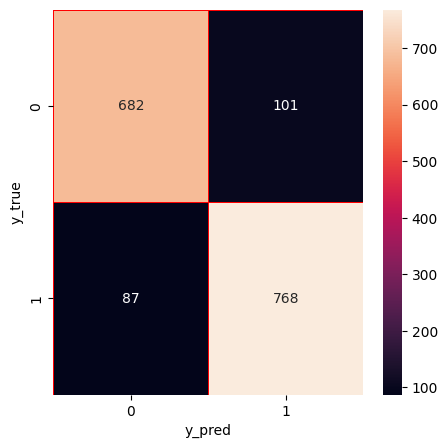

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

f, ax=plt.subplots(figsize=(5,5))
sns.heatmap(cm,annot=True,linewidths=0.5,linecolor="red",fmt=".0f",ax=ax)
plt.xlabel("y_pred")
plt.ylabel("y_true")
plt.show()

In [29]:
docs_new=["https://jpinfotech.org/"]
X_new_counts=tfidf_vectorizer.transform(docs_new)
#X_new_tfidf=tfidf_transformer.fit_transform(X_new_counts)
predicted=rfc.predict(X_new_counts)
print(predicted)
predicted[0]

['legitimate']


'legitimate'

In [30]:
import pickle

In [31]:
pickle.dump(tfidf_vectorizer, open('tfidf_vectorizer.pkl', 'wb'))
pickle.dump(rfc, open('model.pkl', 'wb'))